## rSVD Computational Time

This notebook measures the computational time of:
 1. the matrix-free rSVD to find $K \approx U_k \Sigma_k V_k^T$, versus
 2. Assembling $K = T A^{-1} M$

Using the improved `ExactForwardOperatorFast`. To find $K$, it uses sparse Cholesky factorizations of $M$ and $A$, and the fact that $K^T = M A^{-1} T^T$. Then, forming $Z = A^{-1} T^T \in \mathbb{R}^{N \times N_b}$ requires solving just $N_b$ systems. The total cost is $\mathcal{O}(N^{3/2} \log N)$.

---


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from time import time
from algorithms.rsvd_solvers import MatrixFreeRSVD
from utils.problem_setup import TestProblemsSetup
from utils.exact_forward_operator import ExactForwardOperatorFast
from utils.utils import progress_bar
from utils.utils import disk_cache

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 15,
    'text.usetex': True,
    'text.latex.preamble': r'\usepackage{amsfonts}'
})

/home/elias/miniforge3/envs/fenics_env/lib/python3.9/site-packages/ufl/__init__.py:250: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [ ]:
@disk_cache('../../results/computational_time')
def experiment(N_range, k_list, N_SVD_max, repeat=1):
    """Experiment with assembly of K."""
    record = []

    n_steps, step = len(N_range) * repeat, 1
    for r in range(repeat):
        for N in N_range:
            n = int(np.round(np.sqrt(N)))
            times = {'r': r}
            progress_bar(step, n_steps, end_text=f' [{N=:,}]')
            step += 1

            # Problem setup (only problem I)
            setup = TestProblemsSetup(n=n)
            params = setup.problem_params['I']
            problem = setup.problem_setup(
                params=params, compute_weights=False
            )
            times['N'] = N

            # Matrix-free rSVD (include setup time)
            for k in k_list:
                t0 = time()
                rsvd = MatrixFreeRSVD(problem['V_h'])
                rsvd.solve(k=k, p=5)
                times[f'mfrsvd k{k}'] = time() - t0

            # Assembling K
            t0 = time()
            exact = ExactForwardOperatorFast(V_h=problem['V_h'], assemble_on_init=False)
            K = exact.assemble_K()
            times['assembly'] = time() - t0
            record.append(times)

            # SVD of K
            if N <= N_SVD_max:
                t0 = time()
                np.linalg.svd(K, full_matrices=False)
                times['SVD'] = time() - t0

    return pd.DataFrame(record)


@disk_cache('../../results/computational_time')
def experiment2(N_range, k_list, repeat=1):
    """Experiment without assembly of K."""
    record = []

    n_steps, step = len(N_range) * repeat, 1
    for r in range(repeat):
        for N in N_range:
            n = int(np.round(np.sqrt(N)))
            times = {'r': r}
            progress_bar(step, n_steps, end_text=f' [{N=:,}]')
            step += 1

            # Problem setup (only problem I)
            setup = TestProblemsSetup(n=n)
            params = setup.problem_params['I']
            problem = setup.problem_setup(
                params=params, compute_weights=False
            )
            times['N'] = N

            # Matrix-free rSVD (include setup time)
            for k in k_list:
                t0 = time()
                rsvd = MatrixFreeRSVD(problem['V_h'])
                rsvd.solve(k=k, p=5)
                times[f'mfrsvd k{k}'] = time() - t0

            record.append(times)

    return pd.DataFrame(record)

In [5]:
########## EXPERIMENT 2
repeat = 30
k_list = [10, 25, 50]
N_range = np.linspace(1_000, 100_000, 21, dtype=int)
df = experiment(N_range, k_list, N_SVD_max=100_000, repeat=repeat)
median = df.groupby(['N']).median().reset_index().drop(columns='r')

########## EXPERIMENT 2
N_range = np.linspace(500, 300_000, 20, dtype=int)
df2 = experiment2(N_range, k_list, repeat=repeat)
median2 = df2.groupby(['N']).median().reset_index().drop(columns='r')

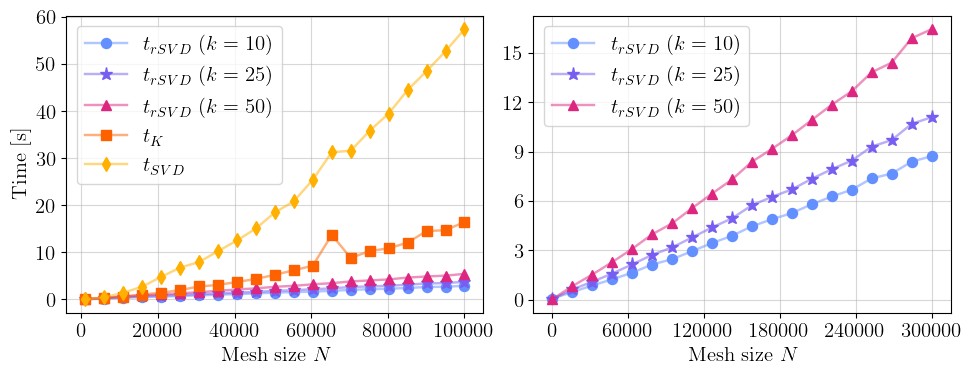

In [7]:
def plot_median(median):
    from utils.colors import C5, M, MS
    from utils.plotting import save_plot
    from matplotlib.lines import Line2D
    from matplotlib.ticker import MaxNLocator
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    ax, ax2 = axes

    labels = ['$t_{rSVD}$ ($k=10$)',
            '$t_{rSVD}$ ($k=25$)',
            '$t_{rSVD}$ ($k=50$)',
            '$t_K$',
            '$t_{SVD}$']
    methods = ['mfrsvd k10',
            'mfrsvd k25',
            'mfrsvd k50',
            'assembly',
            'SVD']

    # Left plot
    for i, method in enumerate(methods):
        ax.plot(median.N, median[method], M[i], ms=MS[i] * 1.2, c=C5[i], lw=1.75)
        ax.plot(median.N, median[method], c=C5[i], lw=1.75, alpha=.5, label=labels[i])

        if method not in ['assembly', 'SVD']:
            ax2.plot(median2.N, median2[method], M[i], ms=MS[i] * 1.2, c=C5[i], lw=1.75)
            ax2.plot(median2.N, median2[method], c=C5[i], lw=1.75, alpha=.5, label=labels[i])

    # Custom labels
    handles, labs = [], []
    for i, method in enumerate(labels):
        legend_line = Line2D([0], [0], color=C5[i], linewidth=1.75, alpha=0.5)
        legend_marker = Line2D([0], [0], color=C5[i], marker=M[i], markersize=MS[i] * 1.2, linestyle='None')
        handles.append((legend_line, legend_marker))
        labs.append(method)

    ax.set_ylabel("Time [s]")
    for axi in axes:
        axi.yaxis.set_major_locator(MaxNLocator(nbins=7))
        axi.xaxis.set_major_locator(MaxNLocator(nbins=6))
        axi.set_xlabel("Mesh size $N$")
        axi.grid(True, alpha=0.5)

    #ax.set_ylim(top=50)
    bbox = (0.77, -0.18)
    ax.legend(handles=handles, labels=labels)#, bbox_to_anchor=bbox)
    ax2.legend(handles=handles[:3], labels=labels[:3])#, bbox_to_anchor=bbox)

    plt.tight_layout()
    fig.subplots_adjust(wspace=0.12)
    save_plot("rsvd_computational_time_comp")
    plt.show()


plot_median(median)

In [17]:
# For what N does rSVD get faster than assembly of K
print("'Assembly' surpasses rSVD at times:")
for k in k_list:
    mask = median['assembly'] > median[f'mfrsvd k{k}']
    pass_val = median.loc[mask, 'N'].iloc[0]
    print(f"N = {int(pass_val)} for k={k}")
print()

print("'SVD' surpasses rSVD at times:")
for k in k_list:
    mask = median['SVD'] > median[f'mfrsvd k{k}']
    pass_val = median.loc[mask, 'N'].iloc[0]
    print(f"N = {int(pass_val)} for k={k}")
print()

# Difference in rSVD across different k
N500 = median2[median2.N == 16263]
N300k = median2[median2.N == 300_000.0]
dt500 = (N500['mfrsvd k50'] / N500['mfrsvd k10']).values
dt300k = (N300k['mfrsvd k50'] / N300k['mfrsvd k10']).values
print("N=500:  Increase k50/k10:", dt500[0])
print("N=300k: Increase k50/k10:", dt300k[0])


'Assembly' surpasses rSVD at times:
N = 1000 for k=10
N = 1000 for k=25
N = 1000 for k=50

'SVD' surpasses rSVD at times:
N = 5950 for k=10
N = 1000 for k=25
N = 5950 for k=50

N=500:  Increase k50/k10: 1.7554765136703911
N=300k: Increase k50/k10: 1.8845028470013363


In [115]:
df['both'] = df['assembly'] + df['SVD']
medians = df.groupby('N').median()

print("N       & rSVD25 & rSVD50 & Assembly & SVD & Both")
for N in medians.index[::5]:
    d = medians[medians.index == N]

    c1 = (d['mfrsvd k25'] / d['mfrsvd k10']).values[0]
    c2 = (d['mfrsvd k50'] / d['mfrsvd k10']).values[0]
    c3 = (d['both'] / d['mfrsvd k10']).values[0]
    c4 = (d['both'] / d['mfrsvd k25']).values[0]
    c5 = (d['both'] / d['mfrsvd k50']).values[0]
    #print(df['both'])
    row = f"{N:<7,} & {c1:.2f} & {c2:.2f} & {c3:.2f} & {c4:.2f} & {c5:.2f} \\\\"
    print(row)
    

N       & rSVD25 & rSVD50 & Assembly & SVD & Both
1,000   & 0.79 & 1.14 & 4.21 & 5.31 & 3.68 \\
25,750  & 1.29 & 1.77 & 11.81 & 9.13 & 6.68 \\
50,500  & 1.26 & 1.85 & 16.21 & 12.84 & 8.78 \\
75,250  & 1.27 & 1.85 & 21.13 & 16.61 & 11.39 \\
100,000 & 1.29 & 1.87 & 25.47 & 19.76 & 13.62 \\
